#### NCSU GIS 714: Geospatial Computation and Simulations

## Spatio-temporal data handling and visualization in GRASS GIS

Additional Resources:
* [GRASS GIS Overview and Manual](https://grass.osgeo.org/grass-stable/manuals/index.html)
* [GRASS book](http://www.grassbook.org/)

## Climate Data Analysis

### Start GRASS GIS

In [12]:
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from datetime import datetime

# Ask GRASS GIS where its Python packages are.
grass_call = "grass84"
shell_setting = True

sys.path.append(
    subprocess.check_output([grass_call, "--config", "python_path"], text=True, shell=shell_setting).strip()
)

# Import GRASS packages
import grass.script as gs
import grass.jupyter as gj

# Start GRASS Session
gj.init("C:\\Users\\Nietolaj\\OneDrive - Mondigroup\\NC State\\Spring 2026\\Geospatial Computation and Simulation\\GIS714-assignments-main\\GIS714-assignments-main\\data\\", "ERA5", "PSum")

Set computational region to the extent of South Africa.

In [13]:
gs.run_command("g.region", n="-22.12", s="-34.84", e="32.95", w="16.25")

List all available raster maps. 

In [15]:
#gs.run_command("g.remove", type="raster", pattern="*", flags="f")
print(gs.read_command("g.list", type="raster"))

### Space-Time Datasets

In [17]:
#gs.run_command("t.remove", inputs="PYear, PSum", flags="f")
#gs.run_command("t.remove", inputs="PSum,PYear, PDry", flags="f")
print(gs.read_command("t.list", type="strds"))

Import rasters as a netcdf.
Skip if rasters already imported.

In [5]:
gs.run_command(
    "r.in.gdal", 
    input = r"C:\Users\Nietolaj\OneDrive - Mondigroup\NC State\Spring 2026\Geospatial Computation and Simulation\Project\R Scripts\PSum_ERA5.tif",
    output = "PSum",
    overwrite=True
)

Create an empty temporal dataset.

In [6]:
gs.run_command(
    "t.create",
    output="PSum",
    type="strds",
    temporaltype="absolute",
    title="Monthly Preciptation",
    description="Monthly Precipitation from 2000 to 2025",
)

Get a list of names of all rasters to be added to the space-time dataset.

In [7]:
import re
names = gs.read_command("g.list", type="raster", pattern="PSum.*", separator=",").strip()
names = names.split(",")
names = sorted(names, key=lambda x: int(re.search(r'\d+$', x).group()))

#For only 2000-2025
names = names[-312:]

names = ",".join(names)
print(names)

PSum.601,PSum.602,PSum.603,PSum.604,PSum.605,PSum.606,PSum.607,PSum.608,PSum.609,PSum.610,PSum.611,PSum.612,PSum.613,PSum.614,PSum.615,PSum.616,PSum.617,PSum.618,PSum.619,PSum.620,PSum.621,PSum.622,PSum.623,PSum.624,PSum.625,PSum.626,PSum.627,PSum.628,PSum.629,PSum.630,PSum.631,PSum.632,PSum.633,PSum.634,PSum.635,PSum.636,PSum.637,PSum.638,PSum.639,PSum.640,PSum.641,PSum.642,PSum.643,PSum.644,PSum.645,PSum.646,PSum.647,PSum.648,PSum.649,PSum.650,PSum.651,PSum.652,PSum.653,PSum.654,PSum.655,PSum.656,PSum.657,PSum.658,PSum.659,PSum.660,PSum.661,PSum.662,PSum.663,PSum.664,PSum.665,PSum.666,PSum.667,PSum.668,PSum.669,PSum.670,PSum.671,PSum.672,PSum.673,PSum.674,PSum.675,PSum.676,PSum.677,PSum.678,PSum.679,PSum.680,PSum.681,PSum.682,PSum.683,PSum.684,PSum.685,PSum.686,PSum.687,PSum.688,PSum.689,PSum.690,PSum.691,PSum.692,PSum.693,PSum.694,PSum.695,PSum.696,PSum.697,PSum.698,PSum.699,PSum.700,PSum.701,PSum.702,PSum.703,PSum.704,PSum.705,PSum.706,PSum.707,PSum.708,PSum.709,PSum.710,PSum.711,P

Register raster maps into  empty space-time dataset.

In [8]:
# Register the rasters to the space time dataset.
gs.run_command(
        "t.register",
        input="PSum",
        maps=names,
        start="2000-01-01",
        increment="1 month"
    )

#Set the computational region to a current raster.
gs.run_command("g.region", raster="PSum.601")

In [9]:
print(gs.read_command("t.info", input="PSum", flags="g"))
#print(gs.read_command("t.info", input="PSum"))

id=PSum@PSum
name=PSum
mapset=PSum
creator=NietoLaJ
temporal_type=absolute
creation_time='2026-03-08 12:53:29.335765'
modification_time='2026-03-08 12:54:26.834549'
semantic_type=mean
start_time='2000-01-01 00:00:00'
end_time='2025-12-01 00:00:00'
granularity='1 month'
map_time=point
north=-21.875
south=-35.125
east=33.125
west=15.875
top=0.0
bottom=0.0
raster_register=raster_map_register_d51a9936211b42dd90e6d31cccd487e0
nsres_min=0.25
nsres_max=0.25
ewres_min=0.25
ewres_max=0.25
min_min=0.0
min_max=7.43866
max_min=65.012451
max_max=846.606262
aggregation_type=None
number_of_semantic_labels=0
semantic_labels=None
number_of_maps=312



### Dataset Animation and Exploration

Extract a small subset for visualization and exploration.

In [10]:
gs.run_command(
    "t.rast.extract",
    input="PSum",
    output="PSum_extract",
    where="start_time >= '2000-01-01' and start_time <= '2026-01-01'",
)

Set the color table for all rasters in the space time raster dataset

In [11]:
gs.run_command("t.rast.colors", input="PSum_extract", color="viridis")

Create and display animation. 

In [ ]:
extract_map = gj.TimeSeriesMap(use_region=True)
extract_map.add_raster_series("PSum_extract")
extract_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
extract_map.d_legend(color="black", at=(10, 90, 0, 2)) #Add legend
#extract_map.save(filename = "precip.gif", font=r"C:\Windows\Fonts\arial.ttf", text_color="black", text_size=18, duration=800)
extract_map.show()

Print the time and monthly maximum of precipitation to find out which months had the highest maximum values. 

In [14]:
#print(gs.read_command("t.rast.list", input="PSum_extract", columns="start_time,max", order="start_time", sep="tab"))

Here, we compute univariate statistics using [t.rast.univar](https://grass.osgeo.org/grass80/manuals/t.rast.univar.html).

In [20]:
#print(gs.read_command("t.rast.univar", input="PSum_extract", where="start_time > '1950-01-01'"))

Remove extracted spatio-temporal datasets.

In [15]:
gs.run_command("t.remove", inputs="PSum_extract", flags="f")
print(gs.read_command("t.list", type="strds"))

PSum@PSum



### Temporal Aggregation

Aggregating to a yearly level.

In [10]:
gs.run_command('t.rast.aggregate', input='PSum',
                output='PYear', base='PYear',
                granularity="1 years", method='sum',
                where="start_time >= '2000-01-01' and start_time <= '2026-01-01'")

In [11]:
gs.run_command("t.rast.colors", input="PYear", color="viridis")

pyear_map = gj.TimeSeriesMap(use_region=True)
pyear_map.add_raster_series("PYear", fill_gaps=True)
pyear_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="white")
pyear_map.d_legend(color="white", at=(10, 90, 0, 2))
#pyear_map.save(filename = "psum_year.gif", font=r"C:\Windows\Fonts\arial.ttf", text_color="white", text_size=18, duration=800)
pyear_map.show()

Finding cells with anomalously high values.

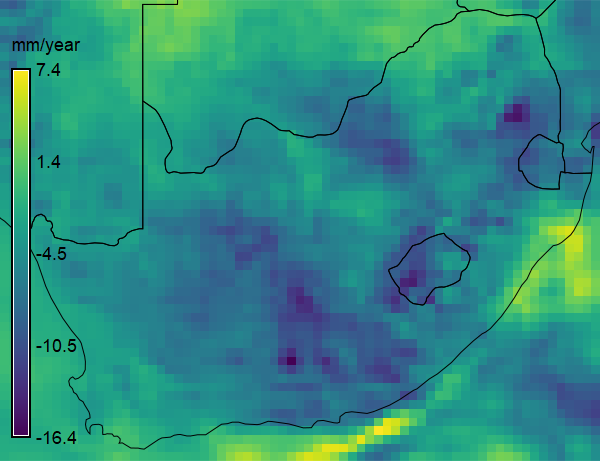

In [43]:
#Try different methods 
#(average,count,median,mode,minimum,min_raster,maximum,max_raster,stddev,range,sum,
#variance,diversity,slope,offset,detcoeff,quart1,quart3,perc90,quantile,skewness,kurtosis)

gs.run_command(
    "t.rast.series",
    input="PYear",
    output="PYear_Stat",
    method="slope"
)

#Flag e centres the colours around zero, flag n inverts them
#gs.run_command("r.colors", map="PYear_Stat", color="differences", flags="en")
gs.run_command("r.colors", map="PYear_Stat", color="viridis")

stat_map = gj.Map()
stat_map.d_rast(map="PYear_Stat")
stat_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
stat_map.d_legend(color="black", raster="PYear_Stat", title="mm/year", at=(5, 85, 2, 5))
stat_map.show()

Computing some other statistics.

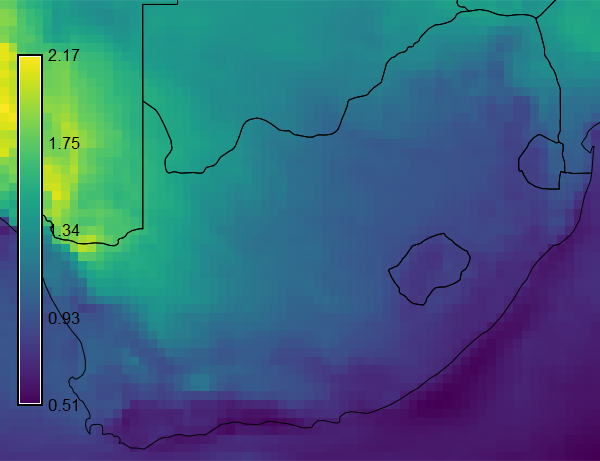

In [44]:
gs.run_command(
    "t.rast.series",
    input="PSum",
    output="PSum_Mean",
    method="average"
)

gs.run_command(
    "t.rast.series",
    input="PSum",
    output="PSum_SD",
    method="stddev"
)

#Coefficient of Variation.
#Lower CV, more consistent values.
gs.run_command("r.mapcalc", expression="PSum_CV = PSum_SD / PSum_Mean")
gs.run_command("r.colors", map="PSum_CV", color="viridis")

stat_map = gj.Map()
stat_map.d_rast(map="PSum_CV")
stat_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
stat_map.d_legend(raster="PSum_CV")
stat_map.show()

Checking how many years the rainfall of each pixel was below a threshold. 

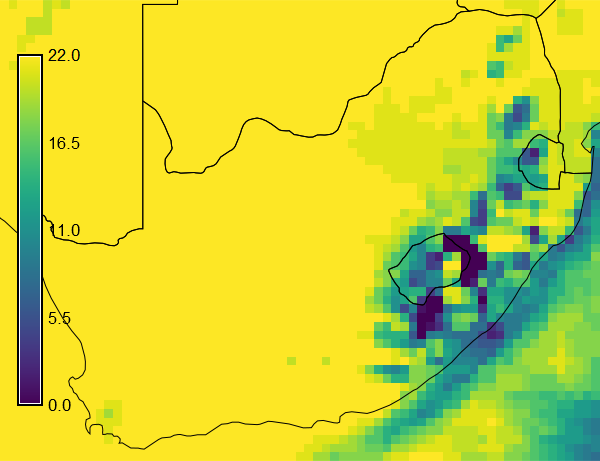

In [47]:
#Counting how many years' rainfall was under a threshold.
gs.run_command(
    "t.rast.mapcalc",
    input="PYear",    
    output="PDry",    
    expression="if(PYear < 1000, 1, 0)",
    basename = "DryYears"
)

gs.run_command(
    "t.rast.series",
    input="PDry",
    output="PDry_Sum",
    method="sum"
)

gs.run_command("r.colors", map="PDry_Sum", color="viridis")

stat_map = gj.Map()
stat_map.d_rast(map="PDry_Sum")
stat_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
stat_map.d_legend(raster="PDry_Sum")
stat_map.show()

Counting the number of months below a threshold rainfall. This takes a few minutes.

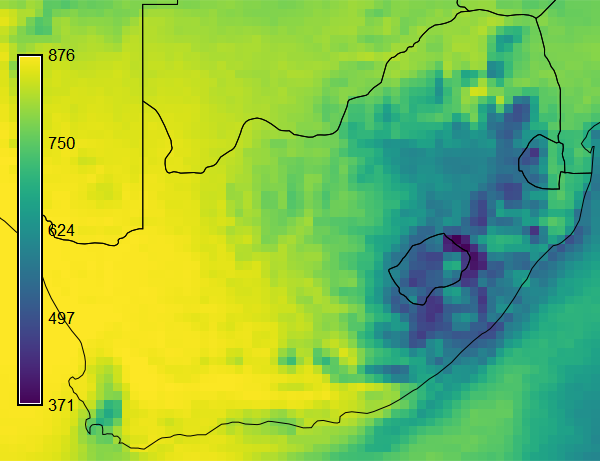

In [48]:
#Counting how many months' rainfall was under a threshold.
gs.run_command(
    "t.rast.mapcalc",
    input="PSum",    
    output="PDry",    
    expression="if(PSum < 100, 1, 0)",
    basename = "DryMonths"
)

#Summing
gs.run_command(
    "t.rast.series",
    input="PDry",
    output="PDry_Sum",
    method="sum"
)

gs.run_command("r.colors", map="PDry_Sum", color="viridis")

stat_map = gj.Map()
stat_map.d_rast(map="PDry_Sum")
stat_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
stat_map.d_legend(raster="PDry_Sum")
stat_map.show()

Accumulating rainfall over thirty years.

In [22]:
!t.rast.accumulate --help

Computes cyclic accumulations of a space time raster dataset.

Usage:
 t.rast.accumulate.py [-nr] input=name output=name [lower=name]
   [upper=name] start=string [stop=string] cycle=string [offset=string]
   [granularity=string] basename=string [suffix=string] limits=lower,upper
   [scale=value] [shift=value] [method=string] [--overwrite] [--help]
   [--verbose] [--quiet] [--ui]

Flags:
  -n   Register empty maps in the output space time raster dataset, otherwise they will be deleted
  -r   Reverse time direction in cyclic accumulation

Parameters:
        input   Name of the input space time raster dataset
       output   Name of the output space time raster dataset
        lower   Input space time raster dataset that defines the lower threshold, values lower than this threshold are excluded from accumulation
        upper   Input space time raster dataset that defines the upper threshold, values higher than this threshold are excluded from accumulation
        start   The temporal s

In [ ]:
gs.run_command(
    "t.rast.accumulate",
    input = "PYear",
    output = "PAcc",
    start = "2000-01-01",
    stop = "2002-01-01",
    cycle = "1 years",
    basename = "Acc",
    limits = "0,1000000"
)

In [ ]:
gs.run_command(
    "t.rast.accdetect",
    input = "PAcc",
    occurrence = "POcc",
    start = "1950-01-01",
    cycle = "30 years",
    basename = "Occ"
)

In [8]:
gs.run_command("t.remove", inputs="PYear,PSum", flags="f")

print(gs.read_command("t.list", type="strds"))

PSum@PSum

